# Paper-Based IMC Workflow

## Step 2: Build adapted MESMER input composites

This notebook continues the paper-based workflow using the **adapted path**.

We are not changing the scientific goal. We still want a workflow that is as close as possible to the paper's preprocessing and segmentation strategy:

- preprocessing in the style of **Steinbock**
- whole-cell segmentation with **MESMER**
- object measurement and downstream analysis after segmentation

However, our ROI export does **not** contain the exact channels used by the paper for segmentation input. So in this step, we build a documented substitute that is defensible for this panel and tissue context.

## What Step 1 established

This is exactly the checkpoint we needed before going further.

### The good news
Your ROI is structurally usable for a paper-based analysis workflow:

- all **43** channels are aligned
- all images are **1000 x 1000** pixels
- all are **16-bit TIFFs**

That means the ROI is internally consistent and technically suitable for downstream multi-channel image processing.

### The limitation
A strict reproduction of the paper's segmentation setup is **not possible** with this ROI export, because the paper used the following MESMER inputs:

- nuclear channel: `HistoneH3 + 191Ir + 193Ir`
- membrane channel: `CD98 + CD3 + CD138 + CD45`

In your exported ROI:

- `191Ir` and `193Ir` are present as the intercalator channels `DNA1` and `DNA2`
- `HistoneH3` is missing
- the membrane markers `CD98` and `CD45` are missing
- only `CD3` and `CD138` overlap directly with the paper's membrane design

So the adapted path is the scientifically honest choice.

## What the adapted path means scientifically

It is important to state this clearly.

We can still build a strong **Steinbock + MESMER-style** workflow, but we should not describe it as an exact replication of the paper's segmentation channel design.

The right language is:

- the workflow is **paper-based**
- the segmentation input channels are **adapted to the available panel**
- the adaptation is fully documented

This is a normal and defensible strategy in imaging analysis when the original acquisition panel differs from the reference study.

The key principle is not to hide the deviation. Instead, we document it explicitly and keep the adaptation biologically motivated.

## Adapted segmentation-channel strategy for this ROI

For this panel, the recommended adapted MESMER inputs are:

### Nuclear composite
- `DNA1`
- `DNA2`

### Membrane composite
- `CD3`
- `CD138`
- `CD31`
- `aSMA`

### Optional boundary-support markers for later evaluation
- `CD20`
- `CD68`
- `CD44`

We are **not** including the optional markers in the core membrane composite at this step. They are being documented as reserve candidates in case the initial MESMER input later proves too weak in some tissue regions.

## Why this adapted channel choice is reasonable

### Why `DNA1 + DNA2` for nuclei
These are not just generic nuclear substitutes. In your ROI, `DNA1` and `DNA2` correspond to the iridium intercalator channels `191Ir` and `193Ir`, which are part of the paper's original nuclear design. What is missing is `HistoneH3`. So the adapted nuclear composite preserves two of the three paper nuclear inputs while using the naming convention present in your exported panel.

### Why keep `CD3 + CD138`
These two markers are already part of the paper's membrane logic. Keeping them preserves as much overlap with the original design as your panel allows.

### Why add `CD31 + aSMA`
This is where the sarcoma context matters. In this tissue, stromal and vascular boundaries are important structural features. `CD31` helps outline endothelial structures, while `aSMA` helps capture stromal or smooth-muscle-like boundaries. Together, they broaden the membrane-context signal available to MESMER.

### Why not use all immune markers immediately
Adding too many markers into a membrane composite can make the image harder to interpret and may blur the difference between boundary signal and phenotype-specific expression. It is usually better to start with a biologically coherent membrane set and only expand if the first attempt is inadequate.

So this Step 2 design is intentionally conservative, documented, and biologically motivated.

## What this step will do

This notebook performs only the following tasks:

1. load the selected nuclear and membrane markers
2. normalize each marker for composite construction
3. create an adapted nuclear composite and an adapted membrane composite
4. visualize the component channels and final composites
5. save the outputs in a clean folder structure for later MESMER use

This notebook will **not** run segmentation yet.

We stop after composite generation so you can review whether the segmentation inputs look biologically and visually reasonable before we proceed.

In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

try:
    from PIL import Image
except ImportError as exc:
    raise RuntimeError('Pillow is required for this notebook step.') from exc

WORKFLOW_ROOT = Path('/Users/rashid/1_IMC_Analysis/11_Vincenzo/paper_based_workflow')
ROI_DIR = Path('/Users/rashid/1_IMC_Analysis/11_Vincenzo/ROI001_D13')

STEP2_ROOT = WORKFLOW_ROOT / 'step2_outputs'
FIGURE_DIR = STEP2_ROOT / 'figures'
MESMER_INPUT_DIR = STEP2_ROOT / 'mesmer_inputs' / ROI_DIR.name

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MESMER_INPUT_DIR.mkdir(parents=True, exist_ok=True)

NUCLEAR_MARKERS = ['DNA1', 'DNA2']
MEMBRANE_MARKERS = ['CD3', 'CD138', 'CD31', 'aSMA']
OPTIONAL_SUPPORT_MARKERS = ['CD20', 'CD68', 'CD44']

print('ROI:', ROI_DIR)
print('Nuclear markers:', NUCLEAR_MARKERS)
print('Membrane markers:', MEMBRANE_MARKERS)
print('Optional support markers:', OPTIONAL_SUPPORT_MARKERS)


ROI: /Users/rashid/1_IMC_Analysis/11_Vincenzo/ROI001_D13
Nuclear markers: ['DNA1', 'DNA2']
Membrane markers: ['CD3', 'CD138', 'CD31', 'aSMA']
Optional support markers: ['CD20', 'CD68', 'CD44']


In [2]:
def parse_marker_name(path: Path) -> str:
    stem = path.name.replace('.ome.tiff', '').replace('.ome.tif', '')
    if '_' in stem:
        return stem.split('_', 1)[1]
    return stem


channel_files = sorted(list(ROI_DIR.glob('*.tif')) + list(ROI_DIR.glob('*.tiff')))
marker_to_path = {parse_marker_name(path): path for path in channel_files}

required_markers = NUCLEAR_MARKERS + MEMBRANE_MARKERS
missing = [marker for marker in required_markers if marker not in marker_to_path]
if missing:
    raise RuntimeError(f'Missing required markers for Step 2: {missing}')

print('All required Step 2 markers are present.')


All required Step 2 markers are present.


## Normalization strategy used for composite construction

At this stage, we are **not** doing the paper's downstream quantitative normalization yet. Here, the goal is different: we want to create visually and structurally meaningful composite images that can be used as segmentation inputs.

So for each channel we:

- load the raw 16-bit TIFF
- convert it to floating point
- clip the intensity using upper-percentile scaling
- rescale it to the interval `[0, 1]`

This makes the channels comparable enough to combine into a composite without allowing a single very bright marker to dominate the image.

This is a **composite-building normalization**, not the final biological normalization used after segmentation.

In [3]:
def load_marker(marker: str) -> np.ndarray:
    with Image.open(marker_to_path[marker]) as img:
        return np.array(img).astype(np.float32)


def normalize_for_composite(image: np.ndarray, low_q: float = 1.0, high_q: float = 99.5) -> np.ndarray:
    low = np.percentile(image, low_q)
    high = np.percentile(image, high_q)
    if high <= low:
        return np.zeros_like(image, dtype=np.float32)
    clipped = np.clip(image, low, high)
    return (clipped - low) / (high - low)


nuclear_images = {marker: normalize_for_composite(load_marker(marker)) for marker in NUCLEAR_MARKERS}
membrane_images = {marker: normalize_for_composite(load_marker(marker)) for marker in MEMBRANE_MARKERS}
support_images = {marker: normalize_for_composite(load_marker(marker)) for marker in OPTIONAL_SUPPORT_MARKERS if marker in marker_to_path}

print('Loaded nuclear images:', list(nuclear_images.keys()))
print('Loaded membrane images:', list(membrane_images.keys()))
print('Loaded optional support images:', list(support_images.keys()))


Loaded nuclear images: ['DNA1', 'DNA2']
Loaded membrane images: ['CD3', 'CD138', 'CD31', 'aSMA']
Loaded optional support images: ['CD20', 'CD68', 'CD44']


## Composite construction logic

We now combine the selected channels by taking the **mean** of the normalized channels in each group.

Why use a mean composite here?

- it keeps the contribution of each marker balanced
- it is simple and transparent to explain
- it avoids overemphasizing one very bright channel

Later, if segmentation quality is poor, we can test other combination rules such as weighted sums or max-based composites. But mean-compositing is a clean and defensible starting point.

In [4]:
nuclear_composite = np.mean(np.stack([nuclear_images[m] for m in NUCLEAR_MARKERS], axis=0), axis=0)
membrane_composite = np.mean(np.stack([membrane_images[m] for m in MEMBRANE_MARKERS], axis=0), axis=0)

print('Nuclear composite shape:', nuclear_composite.shape)
print('Membrane composite shape:', membrane_composite.shape)
print('Nuclear composite range:', float(nuclear_composite.min()), float(nuclear_composite.max()))
print('Membrane composite range:', float(membrane_composite.min()), float(membrane_composite.max()))


Nuclear composite shape: (1000, 1000)
Membrane composite shape: (1000, 1000)
Nuclear composite range: 0.0 1.0
Membrane composite range: 0.0 1.0


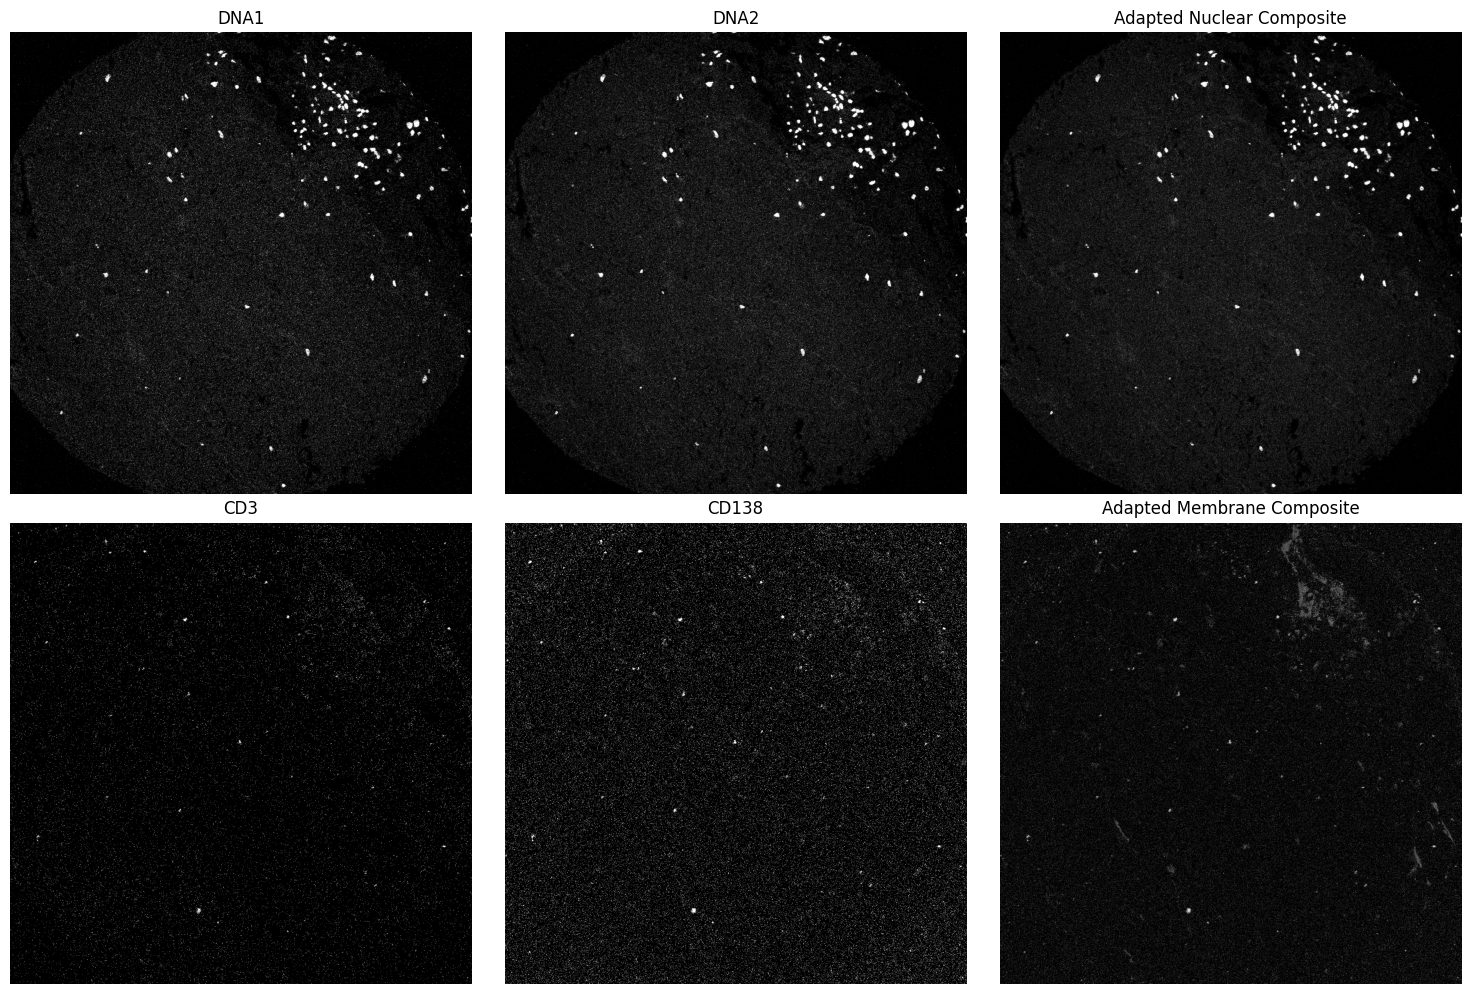

Saved: /Users/rashid/1_IMC_Analysis/11_Vincenzo/paper_based_workflow/step2_outputs/figures/step2_main_composites.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(nuclear_images['DNA1'], cmap='gray')
axes[0, 0].set_title('DNA1')
axes[0, 0].axis('off')

axes[0, 1].imshow(nuclear_images['DNA2'], cmap='gray')
axes[0, 1].set_title('DNA2')
axes[0, 1].axis('off')

axes[0, 2].imshow(nuclear_composite, cmap='gray')
axes[0, 2].set_title('Adapted Nuclear Composite')
axes[0, 2].axis('off')

axes[1, 0].imshow(membrane_images['CD3'], cmap='gray')
axes[1, 0].set_title('CD3')
axes[1, 0].axis('off')

axes[1, 1].imshow(membrane_images['CD138'], cmap='gray')
axes[1, 1].set_title('CD138')
axes[1, 1].axis('off')

axes[1, 2].imshow(membrane_composite, cmap='gray')
axes[1, 2].set_title('Adapted Membrane Composite')
axes[1, 2].axis('off')

plt.tight_layout()
main_preview_path = FIGURE_DIR / 'step2_main_composites.png'
plt.savefig(main_preview_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

print('Saved:', main_preview_path)


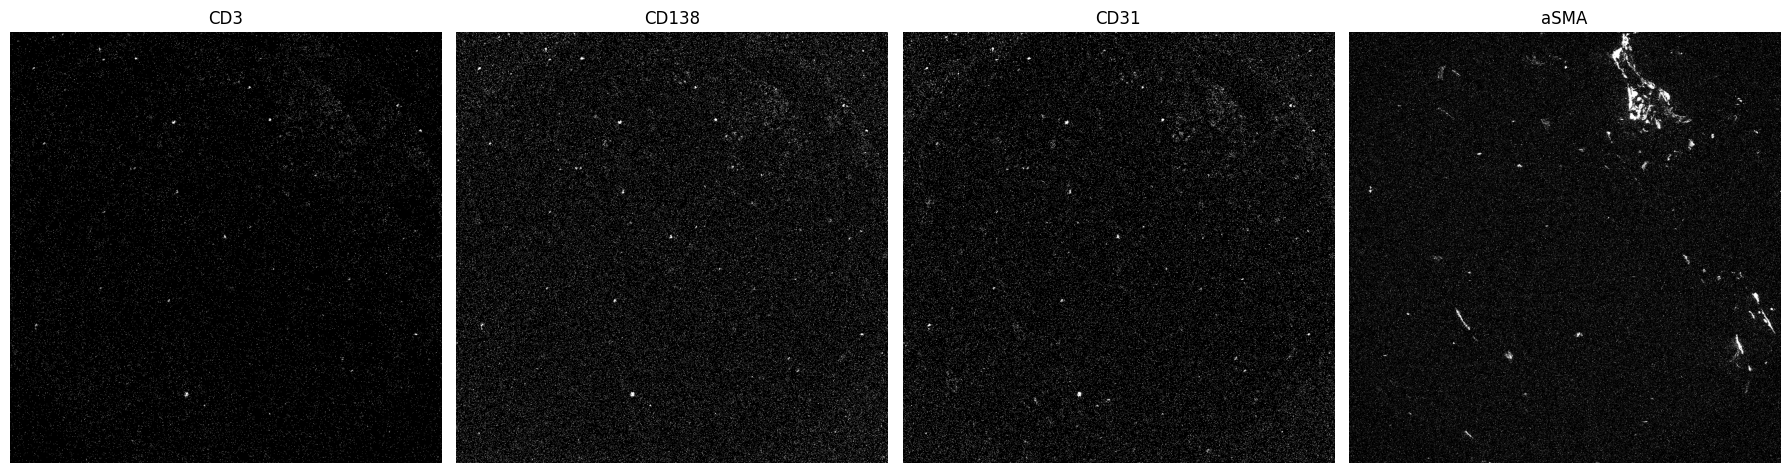

Saved: /Users/rashid/1_IMC_Analysis/11_Vincenzo/paper_based_workflow/step2_outputs/figures/step2_membrane_components.png


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, marker in zip(axes, MEMBRANE_MARKERS):
    ax.imshow(membrane_images[marker], cmap='gray')
    ax.set_title(marker)
    ax.axis('off')
plt.tight_layout()
membrane_panel_path = FIGURE_DIR / 'step2_membrane_components.png'
plt.savefig(membrane_panel_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

print('Saved:', membrane_panel_path)


## Saving the outputs in a MESMER-preparation folder

At this point, we save the adapted composites as separate 16-bit TIFF images.

Why save them this way?

- they remain easy to inspect visually
- they can be reused for later preprocessing steps
- they provide a stable handoff point before actual segmentation

We also save a metadata JSON file that explicitly records:

- which channels were used
- that the workflow is adapted relative to the paper
- which markers were considered optional support markers

This is important for reproducibility and for honest reporting later.

In [7]:
def to_uint16(image_01: np.ndarray) -> np.ndarray:
    image_01 = np.clip(image_01, 0, 1)
    return np.round(image_01 * 65535).astype(np.uint16)


nuclear_tiff_path = MESMER_INPUT_DIR / 'adapted_nuclear_composite.tiff'
membrane_tiff_path = MESMER_INPUT_DIR / 'adapted_membrane_composite.tiff'
metadata_path = MESMER_INPUT_DIR / 'mesmer_input_metadata.json'

Image.fromarray(to_uint16(nuclear_composite)).save(nuclear_tiff_path)
Image.fromarray(to_uint16(membrane_composite)).save(membrane_tiff_path)

metadata = {
    'roi_id': ROI_DIR.name,
    'workflow_mode': 'paper_based_adapted',
    'reference_paper_segmentation': {
        'nuclear': ['HistoneH3', '191Ir', '193Ir'],
        'membrane': ['CD98', 'CD3', 'CD138', 'CD45']
    },
    'adapted_segmentation_inputs': {
        'nuclear': NUCLEAR_MARKERS,
        'membrane': MEMBRANE_MARKERS,
        'optional_support_markers': OPTIONAL_SUPPORT_MARKERS
    },
    'notes': [
        'This ROI does not contain the exact paper channels required for strict segmentation reproduction.',
        'Adapted composites were constructed for MESMER input using available panel markers.',
        'These composites are preparation outputs only; segmentation has not yet been run.'
    ]
}

metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print('Saved nuclear composite:', nuclear_tiff_path)
print('Saved membrane composite:', membrane_tiff_path)
print('Saved metadata:', metadata_path)


Saved nuclear composite: /Users/rashid/1_IMC_Analysis/11_Vincenzo/paper_based_workflow/step2_outputs/mesmer_inputs/ROI001_D13/adapted_nuclear_composite.tiff
Saved membrane composite: /Users/rashid/1_IMC_Analysis/11_Vincenzo/paper_based_workflow/step2_outputs/mesmer_inputs/ROI001_D13/adapted_membrane_composite.tiff
Saved metadata: /Users/rashid/1_IMC_Analysis/11_Vincenzo/paper_based_workflow/step2_outputs/mesmer_inputs/ROI001_D13/mesmer_input_metadata.json


## How to evaluate Step 2 before moving on

Before we proceed to actual segmentation, you should review the generated images and ask:

### 1. Does the nuclear composite look like nuclei?
The nuclear composite should show crisp cell nuclei and not broad diffuse background.

### 2. Does the membrane composite highlight boundaries rather than only cell-type identity?
We want useful boundary context, not just bright phenotype-specific hotspots.

### 3. Do stromal and vascular regions become more interpretable with `CD31 + aSMA` added?
If yes, then the adapted membrane design is doing its job.

If the composites look reasonable, Step 3 can move on to the actual preprocessing handoff for MESMER-style segmentation.

If they do not, then we should refine the membrane composite before touching segmentation.

## Stop point

This notebook stops after creating the adapted segmentation inputs.

The next step would be to prepare and document the actual segmentation stage, but we should only do that after reviewing these composites.